CatBoost: gradient boosting built to handle **categorical features natively**, without manual one-hot or label encoding. Demonstrated on a synthetic customer-churn dataset with several categorical columns. Requires `pip install catboost` (already installed here).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report
from catboost import CatBoostClassifier, Pool
import xgboost as xgb

np.random.seed(42)
n = 2000

contract_type = np.random.choice(['Month-to-month', 'One year', 'Two year'], n, p=[0.55, 0.25, 0.20])
payment_method = np.random.choice(['Electronic check', 'Mailed check', 'Bank transfer', 'Credit card'], n)
internet_service = np.random.choice(['DSL', 'Fiber optic', 'No'], n, p=[0.35, 0.45, 0.20])
gender = np.random.choice(['Male', 'Female'], n)

tenure_months = np.random.randint(1, 72, n)
monthly_charges = np.round(np.random.uniform(20, 120, n), 2)

# Churn probability driven by a mix of categorical and numeric signals
churn_logit = (
    -2.0
    + 1.5 * (contract_type == 'Month-to-month')
    + 0.8 * (payment_method == 'Electronic check')
    + 0.6 * (internet_service == 'Fiber optic')
    - 0.03 * tenure_months
    + 0.01 * monthly_charges
    + np.random.normal(0, 0.5, n)
)
churn_prob = 1 / (1 + np.exp(-churn_logit))
churn = (np.random.rand(n) < churn_prob).astype(int)

df = pd.DataFrame({
    'contract_type': contract_type,
    'payment_method': payment_method,
    'internet_service': internet_service,
    'gender': gender,
    'tenure_months': tenure_months,
    'monthly_charges': monthly_charges,
    'churn': churn,
})
print(df.shape)
print(df['churn'].value_counts(normalize=True))
df.head()

(2000, 7)
churn
0    0.6895
1    0.3105
Name: proportion, dtype: float64


,contract_type,payment_method,internet_service,gender,tenure_months,monthly_charges,churn
0,Month-to-month,Credit card,Fiber optic,Male,1,92.76,1
1,Two year,Bank transfer,Fiber optic,Female,51,65.16,0
2,One year,Bank transfer,DSL,Male,5,105.67,0
3,One year,Bank transfer,Fiber optic,Female,13,114.41,0
4,Month-to-month,Credit card,Fiber optic,Female,19,53.59,1


In [2]:
cat_features = ['contract_type', 'payment_method', 'internet_service', 'gender']
num_features = ['tenure_months', 'monthly_charges']

X = df[cat_features + num_features]
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
cat_idx = [X_train.columns.get_loc(c) for c in cat_features]

In [3]:
# CatBoost: pass categorical columns directly, no encoding needed
cb = CatBoostClassifier(
    iterations=300,
    depth=4,
    learning_rate=0.1,
    cat_features=cat_idx,
    random_state=42,
    verbose=False,
)
cb.fit(X_train, y_train)

y_pred = cb.predict(X_test)
print(f"CatBoost test accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print(classification_report(y_test, y_pred))

CatBoost test accuracy: 72.50%
              precision    recall  f1-score   support

           0       0.76      0.88      0.82       414
           1       0.59      0.38      0.46       186

    accuracy                           0.72       600
   macro avg       0.67      0.63      0.64       600
weighted avg       0.71      0.72      0.71       600



In [4]:
# XGBoost has no native categorical string support here -- must one-hot encode first
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_cat_enc = encoder.fit_transform(X_train[cat_features])
X_test_cat_enc = encoder.transform(X_test[cat_features])

X_train_enc = np.hstack([X_train_cat_enc, X_train[num_features].values])
X_test_enc = np.hstack([X_test_cat_enc, X_test[num_features].values])

xgb_clf = xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.1, random_state=42, eval_metric='logloss')
xgb_clf.fit(X_train_enc, y_train)

print(f"XGBoost test accuracy (after one-hot encoding): {accuracy_score(y_test, xgb_clf.predict(X_test_enc))*100:.2f}%")
print(f"CatBoost test accuracy (no encoding needed):     {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"\nFeature count -- CatBoost: {X_train.shape[1]}, XGBoost after one-hot: {X_train_enc.shape[1]}")

XGBoost test accuracy (after one-hot encoding): 68.83%
CatBoost test accuracy (no encoding needed):     72.50%

Feature count -- CatBoost: 6, XGBoost after one-hot: 14


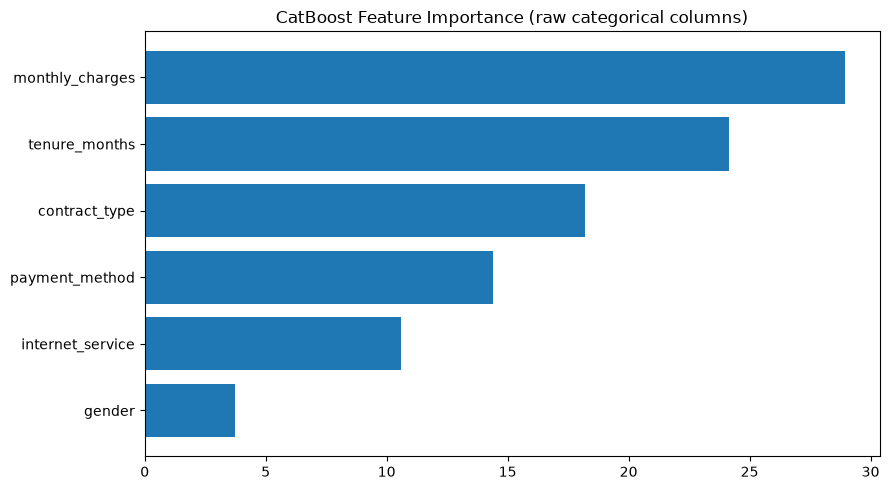

            feature  importance
5   monthly_charges   28.925819
4     tenure_months   24.139716
0     contract_type   18.217591
1    payment_method   14.392653
2  internet_service   10.584171
3            gender    3.740050


In [5]:
# Feature importance (CatBoost reports it directly on the original named columns)
importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': cb.get_feature_importance()
}).sort_values('importance', ascending=False)

plt.figure(figsize=(9, 5))
plt.barh(importances['feature'], importances['importance'])
plt.gca().invert_yaxis()
plt.title('CatBoost Feature Importance (raw categorical columns)')
plt.tight_layout()
plt.show()
print(importances)

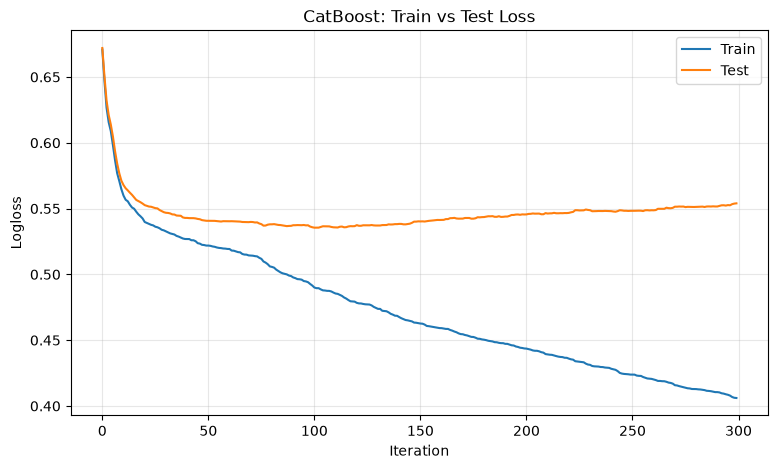

In [6]:
# Training curve via CatBoost's eval_set
cb_eval = CatBoostClassifier(
    iterations=300, depth=4, learning_rate=0.1,
    cat_features=cat_idx, random_state=42, verbose=False,
)
cb_eval.fit(X_train, y_train, eval_set=(X_test, y_test))

evals = cb_eval.get_evals_result()
train_loss = evals['learn']['Logloss']
test_loss = evals['validation']['Logloss']

plt.figure(figsize=(9, 5))
plt.plot(train_loss, label='Train')
plt.plot(test_loss, label='Test')
plt.xlabel('Iteration')
plt.ylabel('Logloss')
plt.title('CatBoost: Train vs Test Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()